In [1]:
import os
import pickle
import pandas as pd
from typing import Dict
from datetime import datetime

from azureml.core import Workspace, Datastore, Dataset

# Paths
EXPOSURE_PATH = "p1_postop/SSL/exposure/preop.csv"
OUTCOME_PATH = "p1_postop/SSL/targets/BLEED.csv"
MAPPING_PATH = "Zahra/032026/Data_OOT/PreMEDS_MDPS/hash_to_integer_map.pkl"
DATASTORE_NAME = "researcher_data"

# Azure config
SUBSCRIPTION_ID = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
RESOURCE_GROUP = 'forskerpl-n0ybkr-rg'
WORKSPACE_NAME = 'forskerpl-n0ybkr-mlw'

# Columns
TIMESTAMP_COL = 'time'
PID_COL = 'subject_id'
ABSPOS_COL = 'abspos'

# Time window
START_DATE = "2020-01-01"
END_DATE = "2021-06-01"

In [2]:
def get_workspace():
    return Workspace(
        subscription_id=SUBSCRIPTION_ID,
        resource_group=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME
    )

ws = get_workspace()
print("Workspace loaded")

Workspace loaded


In [3]:
def print_dataset_summary(exposure_df, outcome_df, title="Dataset Summary"):
    print(f"\n===== {title} =====")
    
    print(f"Exposure data:")
    print(f"   - Records: {len(exposure_df):,}")
    print(f"   - Unique patients: {exposure_df[PID_COL].nunique():,}")
    
    print(f"\nOutcome data:")
    print(f"   - Records: {len(outcome_df):,}")
    print(f"   - Unique patients: {outcome_df[PID_COL].nunique():,}")

In [4]:
def read_csv_from_datastore(ws, datastore_name, path, rename_dict=None):
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, path))
    local_path = dataset.download("./temp", overwrite=True)[0]
    df = pd.read_csv(local_path)

    if rename_dict:
        df = df.rename(columns=rename_dict)

    return df

exposure = read_csv_from_datastore(
    ws, DATASTORE_NAME, EXPOSURE_PATH,
    rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
)

outcome = read_csv_from_datastore(
    ws, DATASTORE_NAME, OUTCOME_PATH,
    rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
)

print("Exposure rows:", len(exposure))
print("Outcome rows:", len(outcome))

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Exposure rows: 767161
Outcome rows: 20856


In [5]:
def clean_data(df):
    df = df.dropna(subset=[TIMESTAMP_COL, PID_COL])
    df = df.drop_duplicates()
    return df

exposure = clean_data(exposure)
outcome = clean_data(outcome)

print("After cleaning:")
print("Exposure:", len(exposure))
print("Outcome:", len(outcome))

After cleaning:
Exposure: 767161
Outcome: 20856


In [6]:
print_dataset_summary(exposure, outcome, title="Before Filtering")


===== Before Filtering =====
Exposure data:
   - Records: 767,161
   - Unique patients: 526,364

Outcome data:
   - Records: 20,856
   - Unique patients: 19,911


In [7]:
def load_mapping(ws, datastore_name, path):
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, path))
    local_path = dataset.download("./temp", overwrite=True)[0]

    with open(local_path, "rb") as f:
        mapping = pickle.load(f)

    return mapping

pid_map = load_mapping(ws, DATASTORE_NAME, MAPPING_PATH)

print("Mapping loaded:", len(pid_map))

{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Mapping loaded: 2218028


In [8]:
def map_pids(df, pid_map):
    df = df.copy()
    df[PID_COL] = df[PID_COL].astype(str).map(pid_map)
    df = df.dropna(subset=[PID_COL])
    df[PID_COL] = df[PID_COL].astype(int)
    return df

exposure = map_pids(exposure, pid_map)
outcome = map_pids(outcome, pid_map)

print("After mapping:")
print("Exposure unique patients:", exposure[PID_COL].nunique())
print("Outcome unique patients:", outcome[PID_COL].nunique())

After mapping:
Exposure unique patients: 526005
Outcome unique patients: 19892


In [9]:
def filter_by_date(df, start, end):
    df = df.copy()
    df["parsed_time"] = pd.to_datetime(df[TIMESTAMP_COL], utc=True, errors="coerce")

    start = pd.to_datetime(start).tz_localize("UTC")
    end = pd.to_datetime(end).tz_localize("UTC")

    df = df[(df["parsed_time"] >= start) & (df["parsed_time"] < end)]
    return df.drop(columns=["parsed_time"])

exposure_filter = filter_by_date(exposure, START_DATE, END_DATE)
outcome_filter = filter_by_date(outcome, START_DATE, END_DATE)

print("After filtering:")
print("Exposure unique patients:", exposure_filter[PID_COL].nunique())
print("Outcome unique patients:", outcome_filter[PID_COL].nunique())

After filtering:
Exposure unique patients: 180947
Outcome unique patients: 5585


In [10]:
print_dataset_summary(exposure_filter, outcome_filter, title="After Filtering")


===== After Filtering =====
Exposure data:
   - Records: 211,570
   - Unique patients: 180,947

Outcome data:
   - Records: 5,719
   - Unique patients: 5,585


In [11]:
def get_hours_since_epoch(series):
    ts = pd.to_datetime(series, utc=True, errors="coerce").dt.tz_localize(None)
    return (ts.view("int64") // 10**9) / 3600

exposure_filter[ABSPOS_COL] = get_hours_since_epoch(exposure_filter[TIMESTAMP_COL]).astype(int)
outcome_filter[ABSPOS_COL] = get_hours_since_epoch(outcome_filter[TIMESTAMP_COL]).astype(int)

print("abspos created")

abspos created


In [12]:
exposure_pids = set(exposure_filter[PID_COL])
outcome_pids = set(outcome_filter[PID_COL])

common_subjects = exposure_pids.intersection(outcome_pids)
missing_subjects = outcome_pids - exposure_pids

print("Unique exposure patients:", len(exposure_pids))
print("Unique outcome patients:", len(outcome_pids))
print("Common patients:", len(common_subjects))
print("Outcome patients WITHOUT exposure:", len(missing_subjects))

coverage = len(common_subjects) / len(outcome_pids)
print("Coverage:", coverage)

Unique exposure patients: 180947
Unique outcome patients: 5585
Common patients: 5341
Outcome patients WITHOUT exposure: 244
Coverage: 0.9563115487914056


In [13]:
def plot_monthly_distribution(df, timestamp_col, title):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd

    df = df.copy()

    # تبدیل به datetime
    df["time_parsed"] = pd.to_datetime(df[timestamp_col], errors="coerce")

    # حذف NaT
    df = df.dropna(subset=["time_parsed"])

    # تبدیل به ماه
    df["month"] = df["time_parsed"].dt.to_period("M").dt.to_timestamp()

    # شمارش
    monthly_counts = df["month"].value_counts().sort_index()

    # plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(monthly_counts.index, monthly_counts.values, width=20)

    # تنظیم محور زمان
    if len(monthly_counts) > 24:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

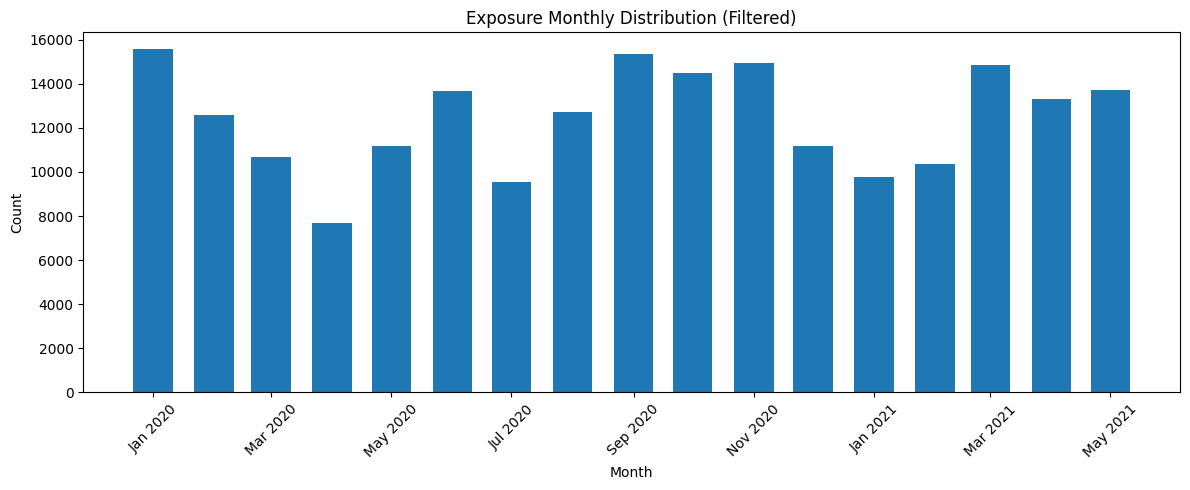

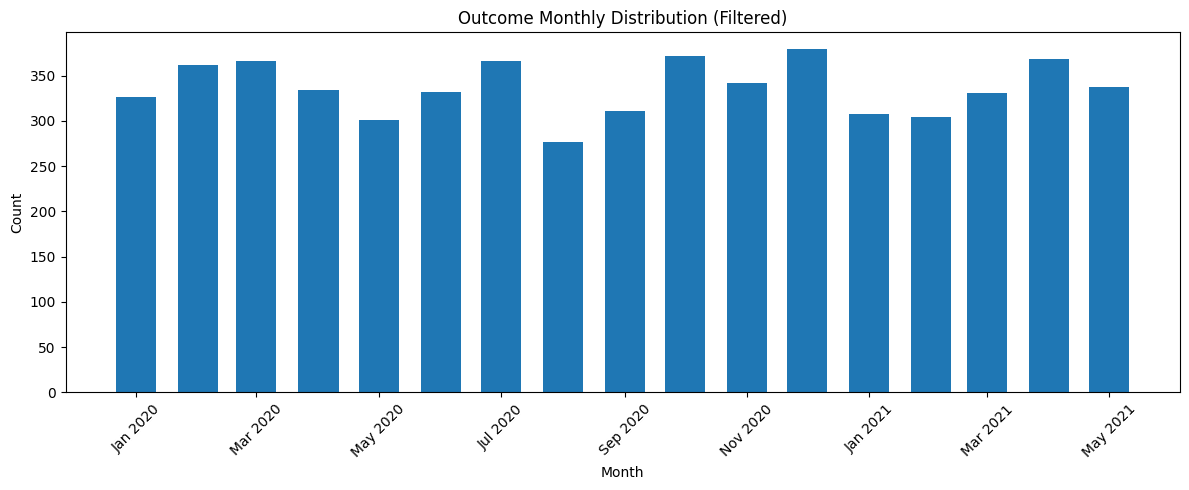

In [14]:
plot_monthly_distribution(
    exposure_filter,
    TIMESTAMP_COL,
    "Exposure Monthly Distribution (Filtered)"
)

plot_monthly_distribution(
    outcome_filter,
    TIMESTAMP_COL,
    "Outcome Monthly Distribution (Filtered)"
)

In [15]:
task_name = "Bleed Prediction"

print(f"Task: {task_name}")         
print(f"   - Exposure data: {len(exposure_filter):,} records from {exposure_filter[PID_COL].nunique():,} unique patients")
print(f"   - Outcome data: {len(outcome_filter):,} records from {outcome_filter[PID_COL].nunique():,} unique patients")

Task: Bleed Prediction
   - Exposure data: 211,570 records from 180,947 unique patients
   - Outcome data: 5,719 records from 5,585 unique patients


In [16]:
import os

# Local save directory
LOCAL_DIR = "./temp_data"
os.makedirs(LOCAL_DIR, exist_ok=True)

# Local file paths
EXPOSURE_LOCAL_PATH = os.path.join(LOCAL_DIR, "exposure_Bleed1.csv")
OUTCOME_LOCAL_PATH = os.path.join(LOCAL_DIR, "outcome_Bleed1.csv")

# Remote directory (ADLS)
REMOTE_DIR = "Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/Bleed"

In [17]:
#  اینجا حتماً از filtered data استفاده کن
exposure_filter.to_csv(EXPOSURE_LOCAL_PATH, index=False)
outcome_filter.to_csv(OUTCOME_LOCAL_PATH, index=False)

print("Files saved locally:")
print(EXPOSURE_LOCAL_PATH)
print(OUTCOME_LOCAL_PATH)

Files saved locally:
./temp_data/exposure_Bleed1.csv
./temp_data/outcome_Bleed1.csv


In [18]:
from azureml.core import Workspace, Datastore
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential
import os

# ---------- Azure Config ----------
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'
datastore_name = "researcher_data"

# ---------- Connect ----------
ws = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(ws, datastore_name)

account_name = datastore.account_name
filesystem_name = datastore.container_name

credential = DefaultAzureCredential()

# ---------- Upload Function ----------
def upload_to_adls2(local_file_path, remote_file_name, directory_path):
    
    # check file exists
    if not os.path.exists(local_file_path):
        raise FileNotFoundError(local_file_path)

    service_client = DataLakeServiceClient(
        account_url=f"https://{account_name}.dfs.core.windows.net",
        credential=credential
    )

    file_system_client = service_client.get_file_system_client(filesystem_name)

    # create directory if not exists
    directory_client = file_system_client.get_directory_client(directory_path)
    try:
        directory_client.create_directory()
    except:
        pass

    file_client = directory_client.get_file_client(remote_file_name)

    print(f"Uploading {remote_file_name} ...")

    with open(local_file_path, "rb") as f:
        file_client.upload_data(f, overwrite=True)

    print(f" Uploaded → {directory_path}/{remote_file_name}")


In [19]:
# ---------- Paths ----------
directory_path = "Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/Bleed"

# ---------- Upload ----------
upload_to_adls2(
    "./temp_data/exposure_Bleed1.csv",
    "exposure.csv",
    directory_path
)

upload_to_adls2(
    "./temp_data/outcome_Bleed1.csv",
    "outcome.csv",
    directory_path
)

Uploading exposure.csv ...
 Uploaded → Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/Bleed/exposure.csv
Uploading outcome.csv ...
 Uploaded → Zahra/032026/CoreBehrt_OOT/CreateOutcome_Finetune/Bleed/outcome.csv


In [20]:
missing_pids = set(outcome_filter[PID_COL]) - set(exposure_filter[PID_COL])

print("Number of missing patients:", len(missing_pids))

Number of missing patients: 244
